# `subgraph`의 입력과 출력을 변환하는 방법

LangGraph에서 `subgraph`는 독립적인 상태(State)와 실행 흐름을 가지는 중첩된 그래프입니다. 복잡한 워크플로우를 기능 단위로 모듈화하거나, 재사용 가능한 구성 요소를 분리하는 데 효과적으로 활용됩니다.

`subgraph`의 **상태**가 `parent graph` 상태와 완전히 독립적일 수 있습니다. 즉, 두 그래프 간에 공유되는 상태 키(state keys)가 전혀 없을 수 있습니다.

이러한 경우에는 `subgraph`를 호출하기 전에 **입력 상태를 변환**하고, 실행 완료 후 **출력 상태를 변환**하는 과정이 필요합니다. 이 변환 작업은 별도의 래퍼(wrapper) 함수를 통해 처리하며, 각 그래프의 독립성을 유지하면서도 유기적으로 연결할 수 있습니다.

이 튜토리얼에서는 `grandchild` → `child` → `parent` 3계층 구조의 그래프를 정의하고, 각 계층 간 상태 변환이 어떻게 이루어지는지 단계별로 살펴보겠습니다.

> 📖 **참고 문서**: [LangGraph Subgraphs](https://docs.langchain.com/oss/python/langgraph/use-subgraphs)

## 환경 설정

서브그래프 상태 변환 예제를 위한 환경을 설정합니다. 환경 변수를 로드하고 LangSmith 추적을 활성화합니다.

아래 코드에서는 환경 설정을 수행합니다.

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적을 설정합니다. https://smith.langchain.com
# !pip install -qU langchain-teddynote
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangGraph-V1-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-V1-Tutorial


## `graph`와 `subgraph` 정의

이 튜토리얼에서는 3계층으로 구성된 그래프 구조를 정의합니다. 각 그래프는 서로 다른 상태 키를 사용하므로, 계층 간 호출 시 반드시 상태 변환이 이루어져야 합니다.

- **`parent graph`**: 최상위 그래프로, `my_parent_key` 상태를 사용합니다.
- **`child subgraph`**: `parent graph`에 의해 호출되며, `my_child_key` 상태를 사용합니다.
- **`grandchild subgraph`**: `child graph`에 의해 호출되며, `my_grandchild_key` 상태를 사용합니다.

세 그래프는 각자 **완전히 독립적인 상태 키**를 가지므로, 직접 연결이 불가능하고 래퍼(wrapper) 함수를 통한 상태 변환이 필요합니다. 가장 안쪽 그래프인 `grandchild`부터 순서대로 정의합니다.

## grandchild 그래프 정의

가장 안쪽의 손자(grandchild) 그래프를 먼저 정의합니다. 이 그래프는 `my_grandchild_key`라는 자체 상태 키를 사용하며, 부모나 자식 그래프의 상태 키와 공유되지 않습니다. 입력값에 `[GrandChild]` 태그를 추가하여 반환합니다.

아래 코드에서는 grandchild 그래프의 상태와 노드를 정의합니다.

In [3]:
# 상태 관리를 위한 TypedDict와 StateGraph 관련 모듈 임포트
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


# 손자 노드의 상태를 정의하는 TypedDict 클래스, 문자열 타입의 my_grandchild_key 포함
class GrandChildState(TypedDict):
    my_grandchild_key: str


# 손자 노드의 상태를 처리하는 함수, 입력된 문자열에 인사말 추가
def grandchild_1(state: GrandChildState) -> GrandChildState:
    # 자식 또는 부모 키는 여기서 접근 불가
    return {"my_grandchild_key": f'([GrandChild] {state["my_grandchild_key"]})'}


# 손자 노드의 상태 그래프 초기화
grandchild = StateGraph(GrandChildState)

# 상태 그래프에 손자 노드 추가
grandchild.add_node("grandchild_1", grandchild_1)

# 시작 노드에서 손자 노드로의 엣지 연결
grandchild.add_edge(START, "grandchild_1")

# 손자 노드에서 종료 노드로의 엣지 연결
grandchild.add_edge("grandchild_1", END)

# 정의된 상태 그래프 컴파일 및 실행 가능한 그래프 생성
grandchild_graph = grandchild.compile()

### grandchild 그래프 시각화

컴파일된 grandchild 그래프를 시각화합니다. 단일 노드(`grandchild_1`)로 구성된 간단한 구조입니다.

아래 코드는 그래프를 시각화합니다.

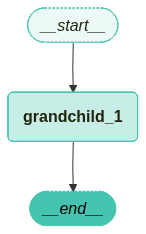

In [4]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(grandchild_graph, xray=True)

### grandchild 그래프 실행 테스트

`subgraphs=True` 옵션을 사용하여 grandchild 그래프를 스트리밍 방식으로 실행합니다. 이 옵션을 활성화하면 서브그래프의 각 실행 단계별 중간 출력을 확인할 수 있으며, 각 청크(chunk)는 `(namespace, state)` 형태의 튜플로 반환됩니다.

아래 코드에서는 grandchild 그래프를 스트리밍으로 실행하고 각 단계의 출력을 확인합니다.

In [5]:
# subgraphs=True 옵션으로 grandchild 그래프를 스트리밍 실행
for chunk in grandchild_graph.stream(
    {"my_grandchild_key": "Hi, Teddy!"}, subgraphs=True
):
    print(chunk)

((), {'grandchild_1': {'my_grandchild_key': '([GrandChild] Hi, Teddy!)'}})


## child 그래프 정의

자식(child) 그래프를 정의합니다. 이 그래프는 `my_child_key`라는 자체 상태 키를 사용합니다. 내부에서 grandchild 그래프를 호출하며, 이때 상태 변환이 필요합니다. `call_grandchild_graph` 함수에서 `my_child_key` → `my_grandchild_key`로 입력을 변환하고, 출력은 다시 `my_child_key`로 변환합니다.

아래 코드에서는 child 그래프를 정의합니다.

In [6]:
# 자식 상태 타입 정의를 위한 TypedDict 클래스
class ChildState(TypedDict):
    my_child_key: str


# 손자 그래프 호출 및 상태 변환 함수, 자식 상태를 입력받아 변환된 자식 상태 반환
def call_grandchild_graph(state: ChildState) -> ChildState:
    # 참고: 부모 또는 손자 키는 여기서 접근 불가능
    # 자식 상태 채널에서 손자 상태 채널로 상태 변환
    grandchild_graph_input = {"my_grandchild_key": state["my_child_key"]}
    # 손자 상태 채널에서 자식 상태 채널로 상태 변환 후 결과 반환
    grandchild_graph_output = grandchild_graph.invoke(grandchild_graph_input)
    return {"my_child_key": f'([Child] {grandchild_graph_output["my_grandchild_key"]})'}


# 자식 상태 그래프 초기화
child = StateGraph(ChildState)

# 노드 추가: 컴파일된 그래프 대신 래퍼 함수(call_grandchild_graph)를 전달
child.add_node("child_1", call_grandchild_graph)
child.add_edge(START, "child_1")
child.add_edge("child_1", END)

# 자식 그래프 컴파일
child_graph = child.compile()

### child 그래프 시각화

컴파일된 child 그래프를 시각화합니다. `child_1` 노드는 `call_grandchild_graph` 함수를 래핑(wrapping)하고 있으며, 내부에서 grandchild 그래프를 호출하는 구조입니다. grandchild 그래프는 별도의 함수로 감싸져 있기 때문에 시각화에서 단일 노드로 표시됩니다.

아래 코드는 그래프를 시각화합니다.

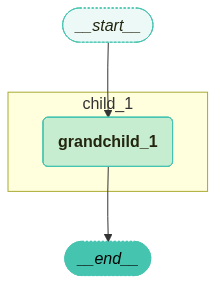

In [7]:
visualize_graph(child_graph, xray=True)

### child 그래프 실행 테스트

`subgraphs=True` 옵션으로 child 그래프를 스트리밍 실행합니다. child 그래프 내부에서 grandchild 그래프가 호출되므로, 출력 결과에서 두 계층의 상태 변환 과정을 순서대로 확인할 수 있습니다. 최종 결과에서 `[Child]`와 `[GrandChild]` 태그가 추가된 값을 통해 상태 변환의 흐름을 파악할 수 있습니다.

아래 코드에서는 child 그래프를 스트리밍으로 실행하고 각 단계의 출력을 확인합니다.

In [8]:
# subgraphs=True 옵션으로 child 그래프를 스트리밍 실행
for chunk in child_graph.stream({"my_child_key": "Hi, Teddy!"}, subgraphs=True):
    print(chunk)

(('child_1:c18d6e7b-1c3a-267a-95ee-31e6af9cd262',), {'grandchild_1': {'my_grandchild_key': '([GrandChild] Hi, Teddy!)'}})
((), {'child_1': {'my_child_key': '([Child] ([GrandChild] Hi, Teddy!))'}})


### 상태 변환의 핵심 원리

`grandchild_graph`의 호출을 별도의 함수(`call_grandchild_graph`)로 감싸는 이유는 두 그래프의 상태 키가 서로 다르기 때문입니다.

이 함수는 grandchild 그래프를 호출하기 전에 `my_child_key` → `my_grandchild_key`로 입력 상태를 변환하고, grandchild 그래프의 출력(`my_grandchild_key`)을 다시 `my_child_key`로 변환하여 child 그래프 상태로 반환합니다.

만약 이러한 변환 없이 `grandchild_graph`를 직접 `.add_node`에 전달하면, child와 grandchild 상태 간에 공유된 상태 키가 없기 때문에 LangGraph에서 오류가 발생합니다.

**중요**: `child subgraph`와 `grandchild subgraph`는 `parent graph`와 공유되지 않는 자신만의 **독립적인** `state`를 가지고 있습니다. 이 독립성이 모듈화의 핵심이며, 각 서브그래프를 독립적으로 테스트하고 재사용할 수 있게 합니다.

## parent 그래프 정의

최상위 부모(parent) 그래프를 정의합니다. 이 그래프는 `my_parent_key`라는 자체 상태 키를 사용합니다. `parent_1` → `child` → `parent_2` 순서로 실행되며, `call_child_graph` 함수에서 `my_parent_key` ↔ `my_child_key` 간의 상태 변환이 이루어집니다.

아래 코드에서는 parent 그래프를 정의합니다.

In [9]:
# 부모 상태 타입 정의를 위한 TypedDict 클래스
class ParentState(TypedDict):
    my_parent_key: str


# 부모 상태의 my_parent_key 값에 '[Parent1]' 문자열을 추가하는 변환 함수
def parent_1(state: ParentState) -> ParentState:
    # 참고: 자식 또는 손자 키는 여기서 접근 불가
    return {"my_parent_key": f'([Parent1] {state["my_parent_key"]})'}


# 부모 상태의 my_parent_key 값에 '[Parent2]' 문자열을 추가하는 변환 함수
def parent_2(state: ParentState) -> ParentState:
    # 참고: 자식 또는 손자 키는 여기서 접근 불가
    return {"my_parent_key": f'([Parent2] {state["my_parent_key"]})'}


# 부모 상태와 자식 상태 간의 데이터 변환 및 자식 그래프 호출 처리
def call_child_graph(state: ParentState) -> ParentState:
    # 참고: 자식 또는 손자 키는 여기서 접근 불가
    # 부모 상태 채널(my_parent_key)에서 자식 상태 채널(my_child_key)로 상태 변환
    child_graph_input = {"my_child_key": state["my_parent_key"]}
    # 자식 상태 채널(my_child_key)에서 부모 상태 채널(my_parent_key)로 상태 변환
    child_graph_output = child_graph.invoke(child_graph_input)
    return {"my_parent_key": child_graph_output["my_child_key"]}


# 부모 상태 그래프 초기화 및 노드 구성
parent = StateGraph(ParentState)
parent.add_node("parent_1", parent_1)

# 노드 추가: 컴파일된 그래프 대신 래퍼 함수(call_child_graph)를 전달
parent.add_node("child", call_child_graph)
parent.add_node("parent_2", parent_2)

# 상태 그래프의 실행 흐름을 정의하는 엣지 구성
parent.add_edge(START, "parent_1")
parent.add_edge("parent_1", "child")
parent.add_edge("child", "parent_2")
parent.add_edge("parent_2", END)

# 구성된 부모 상태 그래프의 컴파일 및 실행 가능한 그래프 생성
parent_graph = parent.compile()

### parent 그래프 시각화

컴파일된 parent 그래프를 시각화합니다. `parent_1` → `child` → `parent_2` 순서로 실행되는 구조를 확인할 수 있습니다. `child` 노드 내부에서는 상태 변환과 함께 child 그래프가 호출됩니다.

아래 코드는 그래프를 시각화합니다.

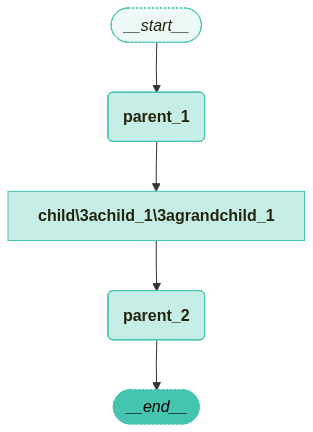

In [10]:
visualize_graph(parent_graph, xray=True)

### parent ↔ child 상태 변환

`child_graph` 호출을 별도의 함수 `call_child_graph`로 감싸는 방식은 child ↔ grandchild 간 변환과 동일한 패턴입니다. 이 함수는 자식 그래프를 호출하기 전에 `my_parent_key` → `my_child_key`로 입력 상태를 변환하고, 자식 그래프의 출력(`my_child_key`)을 다시 `my_parent_key`로 변환하여 부모 그래프 상태로 반환합니다.

변환 없이 `child_graph`를 직접 `.add_node`에 전달하면, 부모와 자식 상태 간에 공유된 상태 키가 없기 때문에 LangGraph에서 오류가 발생합니다. 이처럼 상태 변환 함수는 독립적인 서브그래프를 연결하는 **인터페이스(interface)** 역할을 합니다.

### 전체 그래프 실행 테스트

부모 그래프를 실행하여 상태 변환이 각 계층에서 올바르게 이루어지는지 확인합니다. `subgraphs=True` 옵션을 사용하면 자식 및 손자 서브그래프의 실행 과정도 함께 볼 수 있습니다. 최종 결과에서 `[Parent1]`, `[Child]`, `[GrandChild]`, `[Parent2]` 태그가 순서대로 추가되는 것을 확인할 수 있습니다.

아래 코드에서는 parent 그래프를 실행합니다.

In [11]:
# subgraphs=True 옵션으로 전체 3계층 parent 그래프를 스트리밍 실행
for chunk in parent_graph.stream({"my_parent_key": "Hi, Teddy!"}, subgraphs=True):
    print(chunk)

((), {'parent_1': {'my_parent_key': '([Parent1] Hi, Teddy!)'}})
(('child:4baf6cba-4bb5-8ad5-a543-ee03c7d432c6', 'child_1:526b63c8-6e4c-7325-88e4-66d76d35d557'), {'grandchild_1': {'my_grandchild_key': '([GrandChild] ([Parent1] Hi, Teddy!))'}})
(('child:4baf6cba-4bb5-8ad5-a543-ee03c7d432c6',), {'child_1': {'my_child_key': '([Child] ([GrandChild] ([Parent1] Hi, Teddy!)))'}})
((), {'child': {'my_parent_key': '([Child] ([GrandChild] ([Parent1] Hi, Teddy!)))'}})
((), {'parent_2': {'my_parent_key': '([Parent2] ([Child] ([GrandChild] ([Parent1] Hi, Teddy!))))'}})


## 정리

이 튜토리얼에서는 서로 다른 상태 키를 사용하는 `grandchild`, `child`, `parent` 3계층 서브그래프 구조를 구현하고, 계층 간 상태 변환 방법을 살펴보았습니다.

**핵심 내용 정리:**

- **독립적인 상태**: 각 그래프는 자신만의 상태 키(`my_grandchild_key`, `my_child_key`, `my_parent_key`)를 사용하며, 다른 그래프와 공유하지 않습니다.
- **상태 변환 함수**: 서로 다른 상태 키를 가진 그래프를 연결하려면 래퍼(wrapper) 함수를 통해 입력/출력 상태를 명시적으로 변환해야 합니다.
- **직접 전달 불가**: 상태 키가 공유되지 않는 경우, 컴파일된 서브그래프를 `.add_node`에 직접 전달하면 LangGraph에서 오류가 발생합니다.
- **`subgraphs=True`**: 스트리밍 실행 시 이 옵션을 사용하면 각 서브그래프의 실행 단계를 모두 확인할 수 있습니다.

상태 변환 패턴은 멀티 에이전트 시스템에서 각 에이전트의 독립성을 유지하면서도 유기적으로 연결하는 데 핵심적인 역할을 합니다.